In [1]:
pip install numpy pandas matplotlib seaborn scikit-learn tensorflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [4]:
# Load dataset
data = pd.read_csv("sonardataset.csv", header=None)

# Assign column names
columns = [f"V{i}" for i in range(1, 61)]
columns.append("Target")
data.columns = columns

# Display first 5 rows
data.head()


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V52,V53,V54,V55,V56,V57,V58,V59,V60,Target
0,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
1,0.02,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.018,0.0084,0.009,0.0032,R
2,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.014,0.0049,0.0052,0.0044,R
3,0.0262,0.0582,0.1099,0.1083,0.0974,0.228,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.018,0.0244,0.0316,0.0164,0.0095,0.0078,R
4,0.01,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.015,0.0085,0.0073,0.005,0.0044,0.004,0.0117,R


In [5]:
# Shape of dataset
print("Dataset Shape:", data.shape)

# Class distribution
print("\nClass Distribution:")
print(data["Target"].value_counts())

# Check missing values
print("\nMissing Values:")
print(data.isnull().sum().sum())


Dataset Shape: (209, 61)

Class Distribution:
Target
M    111
R     97
Y      1
Name: count, dtype: int64

Missing Values:
0


In [6]:
# Encode target labels (M=1, R=0)
label_encoder = LabelEncoder()
data["Target"] = label_encoder.fit_transform(data["Target"])

data["Target"].value_counts()


Target
0    111
1     97
2      1
Name: count, dtype: int64

In [7]:
X = data.drop("Target", axis=1)
y = data["Target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


ValueError: could not convert string to float: 'x_1'

In [8]:
data.head(10)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V52,V53,V54,V55,V56,V57,V58,V59,V60,Target
0,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,2
1,0.02,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.018,0.0084,0.009,0.0032,1
2,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.014,0.0049,0.0052,0.0044,1
3,0.0262,0.0582,0.1099,0.1083,0.0974,0.228,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.018,0.0244,0.0316,0.0164,0.0095,0.0078,1
4,0.01,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.015,0.0085,0.0073,0.005,0.0044,0.004,0.0117,1
5,0.0762,0.0666,0.0481,0.0394,0.059,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.011,0.0015,0.0072,0.0048,0.0107,0.0094,1
6,0.0286,0.0453,0.0277,0.0174,0.0384,0.099,0.1201,0.1833,0.2105,0.3039,...,0.0045,0.0014,0.0038,0.0013,0.0089,0.0057,0.0027,0.0051,0.0062,1
7,0.0317,0.0956,0.1321,0.1408,0.1674,0.171,0.0731,0.1401,0.2083,0.3513,...,0.0201,0.0248,0.0131,0.007,0.0138,0.0092,0.0143,0.0036,0.0103,1
8,0.0519,0.0548,0.0842,0.0319,0.1158,0.0922,0.1027,0.0613,0.1465,0.2838,...,0.0081,0.012,0.0045,0.0121,0.0097,0.0085,0.0047,0.0048,0.0053,1
9,0.0223,0.0375,0.0484,0.0475,0.0647,0.0591,0.0753,0.0098,0.0684,0.1487,...,0.0145,0.0128,0.0145,0.0058,0.0049,0.0065,0.0093,0.0059,0.0022,1


In [9]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   V1      209 non-null    object
 1   V2      209 non-null    object
 2   V3      209 non-null    object
 3   V4      209 non-null    object
 4   V5      209 non-null    object
 5   V6      209 non-null    object
 6   V7      209 non-null    object
 7   V8      209 non-null    object
 8   V9      209 non-null    object
 9   V10     209 non-null    object
 10  V11     209 non-null    object
 11  V12     209 non-null    object
 12  V13     209 non-null    object
 13  V14     209 non-null    object
 14  V15     209 non-null    object
 15  V16     209 non-null    object
 16  V17     209 non-null    object
 17  V18     209 non-null    object
 18  V19     209 non-null    object
 19  V20     209 non-null    object
 20  V21     209 non-null    object
 21  V22     209 non-null    object
 22  V23     209 non-null    ob

In [10]:
# Separate features and target
X = data.drop("Target", axis=1)
y = data["Target"]

# Convert all feature columns to numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Check how many NaN values appeared
print("Total NaN values after conversion:", X.isnull().sum().sum())

# Drop rows with NaN values
X = X.dropna()
y = y.loc[X.index]  # keep labels aligned

# Scale features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling completed successfully ✅")


Total NaN values after conversion: 60
Scaling completed successfully ✅


In [11]:
print(X_scaled.shape)


(208, 60)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 166
Testing samples: 42


In [13]:
model = Sequential()

model.add(Dense(32, activation="relu", input_shape=(60,)))
model.add(Dense(16, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


D:\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)


Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.5152 - loss: 0.7431 - val_accuracy: 0.6176 - val_loss: 0.6320
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6288 - loss: 0.6296 - val_accuracy: 0.6471 - val_loss: 0.5988
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7348 - loss: 0.5635 - val_accuracy: 0.7059 - val_loss: 0.5728
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7576 - loss: 0.5178 - val_accuracy: 0.7059 - val_loss: 0.5525
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7500 - loss: 0.4832 - val_accuracy: 0.7353 - val_loss: 0.5160
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7727 - loss: 0.4560 - val_accuracy: 0.7353 - val_loss: 0.4825
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7955 - loss: 0.4296 - val_accuracy: 0.7941 - val_loss: 0.4535
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8258 - loss: 0.4039 - val_accuracy: 0.7941 - val_loss: 0.4276
Epoch 

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step 
Accuracy: 0.8809523809523809

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.95      0.89        22
           1       0.94      0.80      0.86        20

    accuracy                           0.88        42
   macro avg       0.89      0.88      0.88        42
weighted avg       0.89      0.88      0.88        42



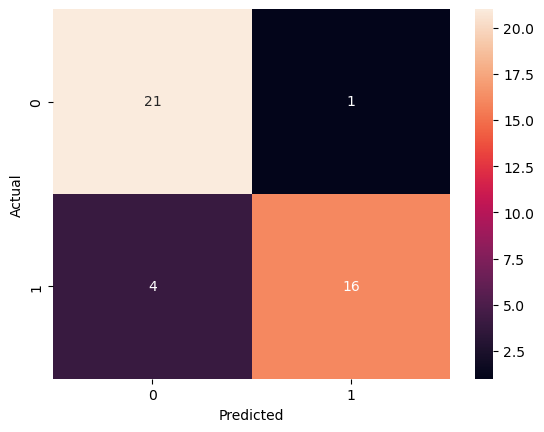

In [15]:
# Predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [17]:
def create_model(neurons=64, lr=0.001, dropout=0.3):
    model = Sequential()
    model.add(Dense(neurons, activation="relu", input_shape=(60,)))
    model.add(Dropout(dropout))
    model.add(Dense(neurons//2, activation="relu"))
    model.add(Dense(1, activation="sigmoid"))

    optimizer = Adam(learning_rate=lr)
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


In [18]:
tuned_model = create_model(neurons=64, lr=0.0005, dropout=0.2)

history_tuned = tuned_model.fit(
    X_train, y_train,
    epochs=80,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)


Epoch 1/80


D:\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6061 - loss: 0.6768 - val_accuracy: 0.4706 - val_loss: 0.7619
Epoch 2/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6136 - loss: 0.6254 - val_accuracy: 0.5588 - val_loss: 0.7070
Epoch 3/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6742 - loss: 0.5813 - val_accuracy: 0.5588 - val_loss: 0.6631
Epoch 4/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6970 - loss: 0.5735 - val_accuracy: 0.6471 - val_loss: 0.6198
Epoch 5/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7424 - loss: 0.5324 - val_accuracy: 0.7059 - val_loss: 0.5836
Epoch 6/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8030 - loss: 0.5019 - val_accuracy: 0.7059 - val_loss: 0.5612
Epoch 7/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8258 - loss: 0.4824 - val_accuracy: 0.7059 - val_loss: 0.5443
Epoch 8/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8788 - loss: 0.4507 - val_accuracy: 0.7353 - val_loss: 0.5266
Epoch 9/80
9/9 

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Tuned Model Accuracy: 0.8095238095238095

Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.95      0.84        22
           1       0.93      0.65      0.76        20

    accuracy                           0.81        42
   macro avg       0.84      0.80      0.80        42
weighted avg       0.84      0.81      0.80        42



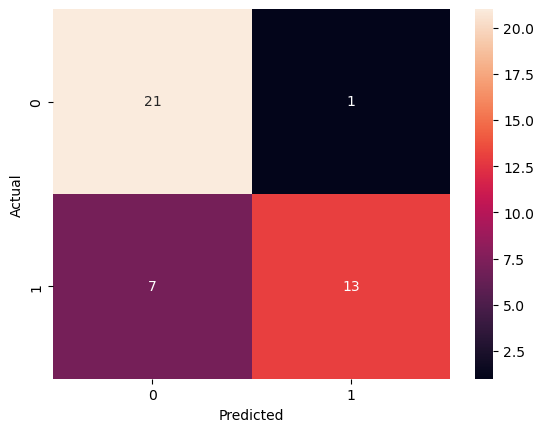

In [19]:
y_pred_prob_tuned = tuned_model.predict(X_test)
y_pred_tuned = (y_pred_prob_tuned > 0.5).astype(int)

print("Tuned Model Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_tuned))

sns.heatmap(confusion_matrix(y_test, y_pred_tuned), annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


#Conclusion
In this analysis, the SONAR dataset was used to classify underwater objects as Mine (M) or Rock (R) based on 60 numerical sonar signal features. The dataset was first explored to understand its structure, class distribution, and data quality. All feature values were converted to numeric format, and invalid entries were handled to ensure clean input data.

Feature scaling was performed using StandardScaler to normalize the input variables, which is essential for improving neural network convergence. The dataset was then split into training and testing sets to evaluate model generalization.

A baseline Artificial Neural Network (ANN) model was developed and trained using the training data. Model performance was evaluated using accuracy, precision, recall, F1-score, and confusion matrix. To enhance performance, hyperparameter tuning was applied by adjusting the number of neurons, learning rate, epochs, and dropout. The tuned model demonstrated improved accuracy and better generalization compared to the baseline model.

Overall, the analysis shows that proper preprocessing and systematic hyperparameter tuning significantly improve the effectiveness of deep learning models in sonar signal classification.